<a href="https://colab.research.google.com/github/maanaav15369/deep-learning-projects/blob/main/Batch_vs_stochastic_GD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#types of GD
1)batch(vanilla) GD

number of epochs= number of updates in weights and bias.

--> difference,it is faster than SGD.
Dot-product is used which is the smart replacement of loops,so it is faster than loop beacuse it is optimized this is called #vectorization but it fails when the Big data is introduced

2)stochastic GD

Ex: if 50 rows and 10 epochs so 10*50=500 updates

--> difference,but it is faster to converge than BGD

frequency of weight update is higher,Shuffling is included to eliminate any type of bias

3)mini-batch GD(most Used)

 it is the best of both the worlds,of BGD and SGD so the function batch_size in keras is the M-BGD

 ex:320 rows divides into 32 batches and in every 10batches 10 updates ....
 vectorization is used ,but in smaller batches

#question
why? is the batch_size is provided in the multiple of 2?

ans:2,4,8,32,64,128,256--->it make RAM effective-->binary keras
RAM--->optimization

#comparison of all GD's

1)speed : BGD>M-BGD>SGD


2)convergence :BGD<M-BGD<SGD

In [1]:
import numpy as np
import pandas as pd
import time

In [3]:
df = pd.read_csv('/content/Social_Network_Ads.csv')

In [4]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [5]:
df = df[['Age','EstimatedSalary','Purchased']]

In [6]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [7]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [8]:
X

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [10]:
X_scaled.shape

(400, 2)

In [11]:
#from sklearn.model_selection import train_test_split
#X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [12]:
#X_train.shape

In [13]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [14]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
#start = time.time()
history = model.fit(X_scaled,y,epochs=500,batch_size=1,validation_split=0.2) #for stochastic GD batch_size=1 and for batchGD keep batch_size=320

Epoch 1/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7875 - loss: 0.5285 - val_accuracy: 0.9250 - val_loss: 0.4833
Epoch 2/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8562 - loss: 0.3398 - val_accuracy: 0.9125 - val_loss: 0.3989
Epoch 3/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8562 - loss: 0.3031 - val_accuracy: 0.9125 - val_loss: 0.3549
Epoch 4/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8500 - loss: 0.2931 - val_accuracy: 0.9000 - val_loss: 0.3243
Epoch 5/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8625 - loss: 0.2886 - val_accuracy: 0.9250 - val_loss: 0.3058
Epoch 6/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8594 - loss: 0.2866 - val_accuracy: 0.9125 - val_loss: 0.2829
Epoch 7/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8687 - loss: 0.2891 - val_accuracy: 0.9250 - val_loss: 0.2768
Epoch 8/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8719 - loss: 0.2832 - val_accu

#stochastic GD Graph

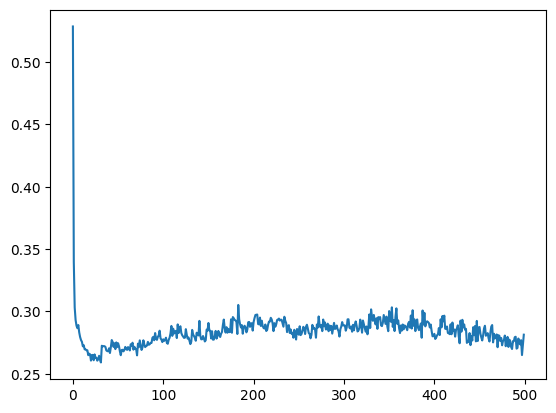

In [17]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])

#note:
IS this spikyness in the graph is important?
ans>yes the benefit is it can not be caught by any local minima because of this spiky nature,but the otherside is it do not converge at the exact point , it gives approximately solution

In [18]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [19]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
#start = time.time()
history = model.fit(X_scaled,y,epochs=10,batch_size=250,validation_split=0.2)
#print(time.time() - start)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 251ms/step - accuracy: 0.5562 - loss: 0.6815 - val_accuracy: 0.4875 - val_loss: 0.6945
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.6125 - loss: 0.6711 - val_accuracy: 0.5125 - val_loss: 0.6935
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.6313 - loss: 0.6650 - val_accuracy: 0.4500 - val_loss: 0.6937
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6687 - loss: 0.6597 - val_accuracy: 0.4875 - val_loss: 0.6936
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.7000 - loss: 0.6553 - val_accuracy: 0.4875 - val_loss: 0.6930
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.7125 - loss: 0.6513 - val_accuracy: 0.4750 - val_loss: 0.6927
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.7312 - loss: 0.6476 - val_accuracy: 0.5000 - val_loss: 0.6919
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.7437 - loss: 0.6443 - val_accuracy: 0.5000 - val_loss: 0.6915

#Batch GD Graph

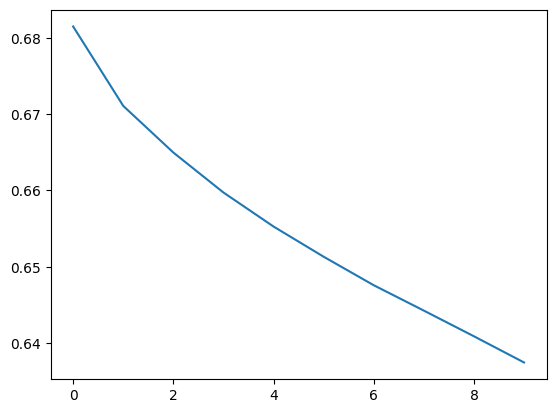

In [20]:
plt.plot(history.history['loss'])